### General Imports:

In [1]:
import os
import gym
from stable_baselines3.ppo import PPO
from stable_baselines3.ppo.policies import MlpPolicy as MLP_PPO
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
import seaborn as sns
from netsim.gym_basic.envs import RMSA_ENV
from netsim.netSimPy import *
from sklearn import tree
from stable_baselines3.common.callbacks import EvalCallback
import numpy as np
import tensorflow as tf
import logging
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
logging.getLogger('tensorflow').setLevel(logging.FATAL)
tf.__version__
from stable_baselines3.common.vec_env import (
    DummyVecEnv,
    is_vecenv_wrapped,
)

/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def warming_lr(initial_lr=1.5e-4, max_warm_lr = 3e-4, final_lr=2e-4, warmup_progress = 0.85):
    def learning_rate_fn(progress):
        if progress >= warmup_progress:
            m = (initial_lr-max_warm_lr)/(1-warmup_progress)
            n = initial_lr - m
            return round(m*progress+n,6)
        else:
            m = (max_warm_lr-final_lr)/ warmup_progress
            return round(m*progress + final_lr,6)
    
    return learning_rate_fn

In [3]:
from typing import Union, Optional

class MyBestCallback(EvalCallback):
    def __init__(
        self,
        eval_env:RMSA_ENV,
        callback_on_new_best = None,
        callback_after_eval = None,
        n_eval_episodes: int = 5,
        eval_freq: int = 10000,
        log_path: Optional[str] = None,
        best_model_save_path: Optional[str] = None,
        deterministic: bool = True,
        render: bool = False,
        verbose: int = 1,
        warn: bool = True,
    ):
        super().__init__(
            eval_env,
            callback_on_new_best,
            callback_after_eval,
            n_eval_episodes,
            eval_freq,
            log_path,
            best_model_save_path,
            deterministic,
            render,
            verbose,
            warn
        )
        self.eval_env = eval_env
        self.best_reward_at = 0

    def _on_step(self) -> bool:
        continue_training = True

        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            # Sync training and eval env if there is VecNormalize
            if self.model.get_vec_normalize_env() is not None:
                try:
                    sync_envs_normalization(self.training_env, self.eval_env)
                except AttributeError as e:
                    raise AssertionError(
                        "Training and eval env are not wrapped the same way, "
                        "see https://stable-baselines3.readthedocs.io/en/master/guide/callbacks.html#evalcallback "
                        "and warning above."
                    ) from e

            # Reset success rate buffer
            self._is_success_buffer = []
            # self.eval_env.reset(hard_reset=True)
            episode_rewards, episode_lengths = evaluate_policy(
                self.model,
                self.eval_env,
                n_eval_episodes=self.n_eval_episodes,
                render=self.render,
                deterministic=self.deterministic,
                return_episode_rewards=True,
                warn=self.warn,
                callback=self._log_success_callback,
            )

            if self.log_path is not None:
                self.evaluations_timesteps.append(self.num_timesteps)
                self.evaluations_results.append(episode_rewards)
                self.evaluations_length.append(episode_lengths)

                kwargs = {}
                # Save success log if present
                if len(self._is_success_buffer) > 0:
                    self.evaluations_successes.append(self._is_success_buffer)
                    kwargs = dict(successes=self.evaluations_successes)

                np.savez(
                    self.log_path,
                    timesteps=self.evaluations_timesteps,
                    results=self.evaluations_results,
                    ep_lengths=self.evaluations_length,
                    **kwargs,
                )

            mean_reward, std_reward = np.mean(episode_rewards), np.std(episode_rewards)
            mean_ep_length, std_ep_length = np.mean(episode_lengths), np.std(episode_lengths)
            self.last_mean_reward = mean_reward

            if self.verbose >= 1:
                print(f"Eval num_timesteps={self.num_timesteps}, " f"episode_reward={mean_reward:.2f} +/- {std_reward:.2f}")
            # Add to current Logger
            self.logger.record("eval/mean_reward", float(mean_reward))
            self.logger.record("eval/mean_ep_length", mean_ep_length)

            if len(self._is_success_buffer) > 0:
                success_rate = np.mean(self._is_success_buffer)
                if self.verbose >= 1:
                    print(f"Success rate: {100 * success_rate:.2f}%")
                self.logger.record("eval/success_rate", success_rate)

            # Dump log so the evaluation results are printed with the correct timestep
            self.logger.record("time/total_timesteps", self.num_timesteps, exclude="tensorboard")
            self.logger.dump(self.num_timesteps)

            if mean_reward > self.best_mean_reward:
                self.best_reward_at = self.num_timesteps
                if self.best_model_save_path is not None:
                    self.model.save(os.path.join(self.best_model_save_path, "best_model"))
                self.best_mean_reward = mean_reward
                # Trigger callback on new best model, if needed
                if self.callback_on_new_best is not None:
                    continue_training = self.callback_on_new_best.on_step()
            print(
                f"Best mean reward: {self.best_mean_reward:.2f} at timestep No. {self.best_reward_at}"
            )
            clear_output(wait=True)
            # Trigger callback after every evaluation, if needed
            if self.callback is not None:
                continue_training = continue_training and self._on_event()

        return continue_training

In [4]:
from netsim.allocators import sap_ff
# FILES AND DIRECTORIES:
__file__ = 'RMSA.ipynb'
absolutepath = os.path.abspath(__file__)
file_name = os.path.basename(os.path.abspath(__file__)).split('.')[0]
fileDirectory = os.path.dirname(os.path.dirname(os.getcwd())) + "/notebooks/networks"
log_dir=f'./tmp/{file_name}/'
os.makedirs(log_dir, exist_ok=True)
tensorboard_log = f"./tb/{file_name}/nsfnet/"

# SIMULATION PARAMS:
# TOTAL_TIMESTEPS = int(12e6)
TOTAL_TIMESTEPS = int(4e6)
EPISODE_LENGTH = 1000
N_EVALUATION_EPISODES = 80
# EVAL_FREQ = N_EVALUATION_EPISODES * EPISODE_LENGTH 
EVAL_FREQ = 50000
N_BLOCKS = 5
N_PATHS = 3
M_LAMBDA = 5000

network = Network(
    networkFileName = fileDirectory + "/RMSA_NSFNet.json",
    pathsFileName=fileDirectory + "/RMSA_NSFNet_routes.json",
    bitrateFilename=fileDirectory + "/RMSA_NSFNet_bitrate.json",
)
generator = EventsGenerator(mLambda=M_LAMBDA)
env_args = dict(
    network = network,
    eventsGenerator=generator,
    j=N_BLOCKS,
    n_paths=N_PATHS,
    episode_length=EPISODE_LENGTH
)
env: RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir)

# MODEL HYPERPARAMETERS:
mArgs = dict(
    # learning_rate=warming_lr(warmup_progress = 0.95),
    # clip_range = 0.1,
    # n_steps= 2048,
    gamma=0.9,
    # ent_coef= 0.01,
    # n_epochs=23,
    # batch_size = 512,
    # ent_coef= 0.0015,
    # n_epochs=27,
    # n_steps= 1024,
    # gamma= 0.95,
    # batch_size = 16,
)
# model = PPO(MLP_PPO, env, verbose=0, seed=3, tensorboard_log=tensorboard_log, **mArgs)
model = PPO(MLP_PPO, env, verbose=0, seed=3, tensorboard_log=tensorboard_log, **mArgs)

# env.setAllocatorFunc(sap_ff)
# callback = CustomCallback(env, eval_freq=EVAL_FREQ, n_eval_episodes=N_EVALUATION_EPISODES, verbose=0, log_path=log_dir)
eval_env:RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir+"eval_env")
# best_model_save_path = os.path.join(log_dir, "best_model")                     
callback = MyBestCallback(
    eval_env,
    n_eval_episodes=N_EVALUATION_EPISODES, 
    eval_freq=EVAL_FREQ,
    log_path=log_dir, 
    best_model_save_path=log_dir,
    verbose=1)
# train_model = model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)
best_model_dir = f"./tmp/RMSA/best_model.zip"
expert = PPO.load(best_model_dir)

In [5]:
def generate_trajectories(n_timesteps, model, env, only_accepted = True):
    trajectories = []
    timesteps_count = 0
    state = None
    done = False
    observation = env.reset()
    
    while (timesteps_count < n_timesteps):
        act, state = model.predict(
                            observation,
                            state=state,
                            episode_start=done,
                            deterministic=True,
                        )
        traj = {
            'obs': observation,
            'action': act
        }
        observation, reward, done, info = env.step(act)
        traj['reward'] = reward
        if only_accepted:
            if reward > 0:
                trajectories.append(traj)
                timesteps_count+=1
        else:
            trajectories.append(traj)
            timesteps_count+=1
        if done:
            env.reset()
    return trajectories

def flatten_trajectories(traj):
    obs = [t['obs'] for t in traj]
    acts = [t['action'] for t in traj]
    rewards = [t['reward'] for t in traj]
    return obs, acts, rewards

class MixerPolicy():
    def __init__(self, expert, student, beta):
        self.student = student
        self.expert = expert
        self.beta = beta
    
    def set(self, expert, student, beta):
        self.student = student
        self.expert = expert
        self.beta = beta
    
    def predict(self, observation, state, episode_start, deterministic):
        model = np.random.choice(["A", "B"], p= [self.beta, 1-self.beta])
        if model == "A":
            return self.expert.predict(observation, state, episode_start, deterministic)
        else:
            return self.student.predict([observation])[0], None

def get_expert_acts(expert, obs, env):
    acts = []
    state = None
    done = False
    env.reset()
    for o in obs:
        act, state = expert.predict(
                        o,
                        state=state,
                        episode_start=done,
                        deterministic=True,
                    )
        acts.append(act)
    return acts

def linear_beta(start, end, steps):
    def call(n):
        return max(start + n*(end-start)/(steps-1), end)
    return call




In [6]:
from sklearn import ensemble
from sklearn.linear_model import RidgeClassifier
from IPython.display import clear_output
import pickle as pkl
import pandas as pd
import json

def decode_action(act, j):
        idx_path = act // j
        idx_block = act % j
        return idx_path, idx_block

def get_route_from_action(acts, j):
    return [decode_action(a, j)[0] for a in acts]


def evaluate_student(student, n_timesteps):
    traj = generate_trajectories(n_timesteps, expert, env)
    x_test = [t['obs'] for t in traj]
    y_test = [t['action'] for t in traj]
    # y_test =  get_route_from_action(y_test, env.j)
    y_pred = student.predict(x_test)

    conf_matrix = confusion_matrix(y_test, y_pred)
    score = accuracy_score(y_test, y_pred)
    print(score, conf_matrix)

def train_with_dagger(expert, env, beta_func, n_rounds, timesteps_by_round, on_round_change = None, trajes_output_name=file_name+'_trajs.csv'):
    student_policy = RidgeClassifier(positive=True)
    print(f"Starting round 1")
    print(f"Sampling new trajectories for round: {1} ")
    obs, acts, _rewards = flatten_trajectories(generate_trajectories(timesteps_by_round, expert, env))
    
    # routes = get_route_from_action(acts, env.j)
    student_policy.fit(obs, acts)
    evaluate_student(student_policy, 100000)
    
    for r in range(1, n_rounds):
        print(f"Starting round {r+1}")
        mixer = MixerPolicy(expert, student_policy, beta = beta_func(r))
        print(f"Sampling new trajectories for round: {r+1} ")
        obs2, _acts, _rewards = flatten_trajectories(generate_trajectories(timesteps_by_round, mixer, env))
        acts2 = get_expert_acts(expert, obs2, env)
        
        # extend and update:
        shuffle = np.arange(len(obs2))
        np.random.shuffle(shuffle)
        obs2 = [obs2[s] for s in shuffle]
        acts2 = [acts2[s] for s in shuffle]
        obs.extend(obs2)
        acts.extend(acts2)

        # print(f"Saving trajectories for round: {r+1} ")
        # df = pd.DataFrame({'x':[json.dumps(o.tolist(),separators=(',', ':')) for o in obs2], 'y':acts2})
        # df.to_csv(trajes_output_name,
        #             mode="a",
        #             index=False,
        #             header=False
        #         )
        print(f"Fitting student for round: {r+1} ")
        # clear_output(wait=True)
        student_policy.fit(obs, acts)
        evaluate_student(student_policy, 100000)
        
    return student_policy

In [7]:
n_steps = 8
beta_func = linear_beta(1, 0, n_steps)
student = train_with_dagger(expert, env, beta_func, n_steps,timesteps_by_round=200000)

Starting round 1
Sampling new trajectories for round: 1 
0.61831 [[50352   241   192    97     0   514   238     0     0   158    51  1140
      0]
 [ 3989   124    70     1     0   948    38     0     0   140     1   101
      0]
 [ 2095    89   581     1     0  1844   393     0     0   421     0   146
      0]
 [    2     0     0     0     0     0     0     0     0     0     0     0
      0]
 [    0     1     0     0     0     0     0     0     0     0     0     1
      0]
 [ 5137    36   149     2     0  7145   109     0     0   612     8   116
      0]
 [ 2435     1   100     2     0   817   839     0     0   574     3   295
      0]
 [ 1113     1     5    14     0   334   143     0     0    27    23    96
      0]
 [    3     0     0     0     0     0     0     0     0     1     0     0
      0]
 [ 5415    43   150     0     0  1847    43     0     0   797     2    87
      0]
 [  344     0     6     4     0   436   401     0     0   648    12   472
      0]
 [  801   147   291   

### Saving the agent

In [8]:
pickle_out = open("student_LR.pkl","wb")
pkl.dump(student,pickle_out)
pickle_out.close()
# pickle_out = open("student_LR.pkl","rb")
# student = pkl.load(pickle_out)
# pickle_out.close()

In [9]:

def get_actions_count(y_test):
    y1_test = [0]*15
    for yv in y_test:
        y1_test[yv] += 1
    return y1_test
    

### Global accuracy

In [10]:
traj = generate_trajectories(200000, expert, env)
x_test = [t['obs'] for t in traj]
y_test = [int(t['action']) for t in traj]

# y_pred = predict(x_test,student, env)
y_pred = student.predict(x_test)
score = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred,labels=[i for i in range(15)])
print(score)
print(conf_matrix)
print(f1_score(y_test,y_pred, average='weighted'))

0.613115
[[99637   540   328     2     0   999   509     2     0   232   443   139
   2734     0    25]
 [ 7896   234   161     0     0  1798    77     0     0     3   289     2
    218     0     0]
 [ 3894   223   778     0     0  4118   773     0     0     4   987     0
    274     0     0]
 [    3     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [    1     0     0     0     0     0     1     0     0     0     0     0
      1     0     0]
 [10199    97   196     1     0 14315   206     0     0     5  1507     8
    251     0     1]
 [ 4866     6   118     0     0  1780  1697     0     0     2  1252     9
    497     0     2]
 [ 2213     5    15     0     0   762   317     1     0    32    96    85
    226     0     4]
 [    3     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [10504    76   301     0     0  3493   1

In [21]:
get_metrics(conf_matrix)

Clase 1:
  Precision: 0.7917
  F1-score: 0.8679
  Sensibilidad (Recall): 0.9602
  Especificidad: 24.1121

Clase 2:
  Precision: 0.3966
  F1-score: 0.1730
  Sensibilidad (Recall): 0.1106
  Especificidad: 0.1244

Clase 3:
  Precision: 0.4936
  F1-score: 0.3309
  Sensibilidad (Recall): 0.2488
  Especificidad: 0.3313

Clase 4:
  Precision: 0.5000
  F1-score: 0.0026
  Sensibilidad (Recall): 0.0013
  Especificidad: 0.0013

Clase 5:
  Precision: 0.0000
  F1-score: nan
  Sensibilidad (Recall): 0.0000
  Especificidad: 0.0000



/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_4074/2585605376.py:6: RuntimeWarning: invalid value encountered in divide
  f1_score = 2 * (precision * recall) / (precision + recall)


### Inter-path accuracy

In [13]:

n_conf_matrix = np.zeros(shape=(3,3))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n_conf_matrix[ir//5,ic//5] += conf_matrix[ir][ic]

def score(matrix):
    total = sum(matrix.reshape(-1,1))
    correct = np.trace(matrix)
    return correct/total
s = score(n_conf_matrix)
print(s[0])
print(n_conf_matrix)


0.706835
[[113697.   8516.   5112.]
 [ 17719.  19117.   3938.]
 [ 14359.   8989.   8553.]]


In [14]:
def get_metrics(matrix):
    # Calcula métricas
    precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)
    recall = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
    specificity = np.diag(confusion_matrix) / (np.sum(confusion_matrix, axis=1) - np.diag(confusion_matrix))
    f1_score = 2 * (precision * recall) / (precision + recall)
    
    # Imprime las métricas
    for i in range(len(precision)):
        print(f"Clase {i + 1}:")
        print(f"  Precision: {precision[i]:.4f}")
        print(f"  F1-score: {f1_score[i]:.4f}")
        print(f"  Sensibilidad (Recall): {recall[i]:.4f}")
        print(f"  Especificidad: {specificity[i]:.4f}\n")

# Matriz de confusión proporcionada
confusion_matrix = np.array(n_conf_matrix)

get_metrics(confusion_matrix)



Clase 1:
  Precision: 0.7799
  F1-score: 0.8326
  Sensibilidad (Recall): 0.8930
  Especificidad: 8.3429

Clase 2:
  Precision: 0.5220
  F1-score: 0.4940
  Sensibilidad (Recall): 0.4689
  Especificidad: 0.8827

Clase 3:
  Precision: 0.4859
  F1-score: 0.3455
  Sensibilidad (Recall): 0.2681
  Especificidad: 0.3663



### Inter-spectrum accuracy

In [15]:
n2_conf_matrix = np.zeros(shape=(5,5))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n2_conf_matrix[ir%5,ic%5] += conf_matrix[ir][ic]

def score(matrix):
    total = sum(matrix.reshape(-1,1))
    correct = np.trace(matrix)
    return correct/total
s = score(n2_conf_matrix)
print(s[0])
print(n2_conf_matrix)


0.758215
[[1.43009e+05 1.67800e+03 3.98200e+03 3.00000e+00 2.68000e+02]
 [2.07450e+04 2.81200e+03 1.84600e+03 0.00000e+00 1.10000e+01]
 [1.49210e+04 2.45900e+03 5.81900e+03 0.00000e+00 1.85000e+02]
 [1.95400e+03 1.41000e+02 1.42000e+02 3.00000e+00 1.90000e+01]
 [1.00000e+00 1.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00]]


In [16]:
# Matriz de confusión proporcionada
confusion_matrix = np.array(n2_conf_matrix)

get_metrics(confusion_matrix)

Clase 1:
  Precision: 0.7917
  F1-score: 0.8679
  Sensibilidad (Recall): 0.9602
  Especificidad: 24.1121

Clase 2:
  Precision: 0.3966
  F1-score: 0.1730
  Sensibilidad (Recall): 0.1106
  Especificidad: 0.1244

Clase 3:
  Precision: 0.4936
  F1-score: 0.3309
  Sensibilidad (Recall): 0.2488
  Especificidad: 0.3313

Clase 4:
  Precision: 0.5000
  F1-score: 0.0026
  Sensibilidad (Recall): 0.0013
  Especificidad: 0.0013

Clase 5:
  Precision: 0.0000
  F1-score: nan
  Sensibilidad (Recall): 0.0000
  Especificidad: 0.0000



/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_4074/2585605376.py:6: RuntimeWarning: invalid value encountered in divide
  f1_score = 2 * (precision * recall) / (precision + recall)


In [17]:
def evaluate_bp_student(student, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.setLambda(mLambda)   
    observation = env.reset()
    accepted_requests = 0
    
    while (timesteps_count < n_timesteps):
        # act = predict([observation], student, env)[0]
        act = student.predict([observation])[0]
        observation, reward, done, info = env.step(act)
        if reward == 1:
            accepted_requests+=1
        if done:
            env.reset()
        timesteps_count+=1
    return 1 - accepted_requests/n_timesteps


def evaluate_expert(expert, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.setLambda(mLambda)
    observation = env.reset()
    accepted_requests = 0
    
    while (timesteps_count < n_timesteps):
        act, state = expert.predict(
                            observation,
                            state=state,
                            episode_start=done,
                            deterministic=True,
                        )
        observation, reward, done, info = env.step(act)
        if reward == 1:
            accepted_requests+=1
        if done:
            env.reset()
        timesteps_count+=1
    return 1 - accepted_requests/n_timesteps


# loads = [1000, 1200, 1400, 1600, 1800, 2000,]
# results = {
#     "model": [],
#     "student": [],
# }
# N_EVALUATIONS = 400000

# for l in loads:
#     env.setAllocatorFunc(None)
#     # agent_model, _ = evaluate_policy(env, n_eval_episodes=N_EVALUATION_EPISODES, model = model, return_dataframe=False, return_episode_rewards=False, seed=1)
#     bp = evaluate_expert(expert, N_EVALUATIONS, l)
#     print("model",bp)
#     results["model"].append(bp)
    
#     bp = evaluate_bp_student(student, N_EVALUATIONS, l)
#     print("student",bp)
#     results["student"].append(bp)



In [24]:
loads = [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500 ]
N_EVALUATIONS = 2000000
lr_bp = []

for l in loads:
    bp = evaluate_bp_student(student, N_EVALUATIONS, l)
    lr_bp.append(round(bp, 7) )
print(lr_bp)

[0.0001385, 0.0005445, 0.0015725, 0.0032095, 0.0055755, 0.008636, 0.012214, 0.0161315]


### features importance

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 8.67351768e-06
 1.53787110e-05 1.82484269e-05 8.85333479e-06 7.50228136e-06
 4.49846188e-06 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 4.55907183e-06 8.11241754e-06
 2.47298351e-05 0.00000000e+00 3.46070813e-06 2.14686640e-06
 0.00000000e+00 1.54154814e-03 3.48981561e-05 1.09254047e-03
 6.85225185e-04 0.00000000e+00 2.60968078e-04 0.00000000e+00
 0.00000000e+00 2.44297008e-04 0.00000000e+00 0.00000000e+00
 0.00000000e+00 8.95775107e-04 6.63368530e-04 9.34101032e-04
 9.95918597e-05 7.65074679e-04 0.00000000e+00 0.00000000e+00
 1.85228504e-03 0.00000000e+00 4.08813477e-04 5.66255900e-05
 0.00000000e+00 0.00000000e+00 1.05552525e-03 8.43842156e-04
 1.09964204e-03 1.61577882e-03 8.73123047e-04 0.00000000e+00
 2.02702402e-04 0.00000000e+00 0.00000000e+00 1.38938431e-03
 3.31541215e-04 0.000000

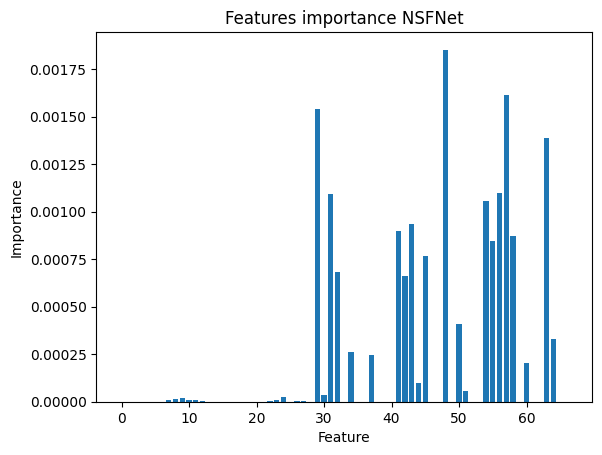

In [26]:
import pandas as pd

base_output_dir_features = f'./plots/{__file__}/features_importance_heuristic/'

output_dir = base_output_dir_features
os.makedirs(output_dir, exist_ok=True)

# print("lolo",student.coef_[0])
# print("lolo",len(student.get_params()))

importances_sk = student.coef_[0]
importance = pd.DataFrame(importances_sk)
importance.to_csv(f'{output_dir}features_importance_heuristic.csv')
print(importances_sk)
plt.figure()
plt.bar([x for x in range(len(importances_sk))], importances_sk)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title(f"Features importance NSFNet")
plt.savefig(output_dir + 'NSFNet.png')
plt.show()